# Estimate diameter from phase function

In [1]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pickle

# import seaborn as sns
# sns.set_context("poster")

### Combination BFT & SSOFT

In [2]:
cols = [
    "sso_number",
    "sso_name",
    "sso_class",
    "albedo.value",
    "diameter.value",
]

# Read BFT with rocks
bft = rocks.load_bft(columns=cols)

In [3]:
# bft[bft["spins.1.period.value"] == bft["spins.1.period.value"]].groupby("spins.1.period_flag").count()

In [4]:
print(
    "{:,} diameters available in the BFT".format(
        len(bft[bft["diameter.value"].notna()])
    )
)

149,478 diameters available in the BFT


In [5]:
# You need SSOFT version 2024.09
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [6]:
flavor = "SHG1G2"
filt = "r"

## Comparison to literature

In [7]:
# Keep only known periods 1 in the BFT
data = ssoft.merge(bft, left_on="name", right_on="sso_name", how="left")
data = data[data["diameter.value"].notna()]

# sort by number of observations
data = data.sort_values("n_obs", ascending=False)
# data = data.sort_values(f'{flavor}_rms', ascending=False)

col_display = [
    "sso_number",
    "sso_name",
    "n_obs",
    "sso_class",
    "diameter.value",
    f"{flavor}_period",
    f"{flavor}_rms",
]

if flavor == "SHG1G2":
    col_display.append(f"{flavor}_R")

cond = data.sso_class.str.contains("Inner")
# cond = (data['spins.1.technique']=='LCI') & ( np.abs(data['spins.1.period.value']-data['SSHG1G2_period']) < 0.1)

data.loc[cond, col_display].head(5)

,sso_number,sso_name,n_obs,sso_class,diameter.value,SHG1G2_period,SHG1G2_rms,SHG1G2_R
63906,5518,Mariobotta,451.0,MB>Inner,7.107,33.183693,0.169943,0.789760
84016,21814,Shanawolff,431.0,MB>Inner,3.917,2.499411,0.056240,0.865430
30332,1928,Summa,409.0,MB>Inner,9.333,48.055374,0.116187,0.300000
51067,2200,Pasadena,405.0,MB>Inner,7.197,20.530388,0.068762,0.818853
91906,5350,Epetersen,394.0,MB>Inner,5.930,4.549254,0.111522,0.746113


In [8]:
print(
    "{:,} diameter available in the BFT x Fink".format(
        len(data[data["diameter.value"].notna()])
    )
)

77,121 diameter available in the BFT x Fink


### Mask

It is not obvious yet what are the criteria for good period estimation, so let's stick with masks defined for sHG1G2

In [9]:
maskFINK_inter = compute_mask(
    ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model="FINK", kind="inter"
)
maskFINK_union = compute_mask(
    ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model="FINK", kind="union"
)

for model in ["HG", "HG1G2", "SHG1G2", "FINK"]:
    print_statistics(ssoft, model)
    print()

mask = maskFINK_union
mask = maskFINK_inter
print(sum(mask))

  All data       : 140559  (100.00%)
  Mask HG (g∩r) : 137746  ( 98.00%)
  Mask HG (gUr) : 137752  ( 98.00%)

  All data       : 140559  (100.00%)
  Mask HG1G2 (g∩r) :  57578  ( 40.96%)
  Mask HG1G2 (gUr) : 101207  ( 72.00%)

  All data       : 140559  (100.00%)
  Mask SHG1G2 (g∩r) :  76798  ( 54.64%)
  Mask SHG1G2 (gUr) : 114519  ( 81.47%)

  All data       : 140559  (100.00%)
  Mask FINK (g∩r) :  57198  ( 40.69%)
  Mask FINK (gUr) :  95470  ( 67.92%)

57198


In [10]:
print(
    "{:,} diameter available in the MASK(BFT x Fink)".format(
        len(data[data["diameter.value"].notna()][mask])
    )
)

33,447 diameter available in the MASK(BFT x Fink)


/tmp/ipykernel_18962/3609663374.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(data[data["diameter.value"].notna()][mask])


### Period distribution

In [11]:
data.columns[data.columns.str.contains("SH")]

Index(['SHG1G2_chi2red', 'SHG1G2_min_cos_lambda', 'SHG1G2_mean_cos_lambda',
       'SHG1G2_max_cos_lambda', 'SHG1G2_status', 'SHG1G2_fit', 'SHG1G2_rms',
       'SHG1G2_rms_g', 'SHG1G2_rms_r', 'SHG1G2_median_error_phot',
       'SHG1G2_median_error_phot_1', 'SHG1G2_median_error_phot_2', 'SHG1G2_R',
       'SHG1G2_dR', 'SHG1G2_alpha0', 'SHG1G2_dalpha0', 'SHG1G2_delta0',
       'SHG1G2_ddelta0', 'SHG1G2_H_g', 'SHG1G2_dH_g', 'SHG1G2_G1_g',
       'SHG1G2_dG1_g', 'SHG1G2_G2_g', 'SHG1G2_dG2_g', 'SHG1G2_H_r',
       'SHG1G2_dH_r', 'SHG1G2_G1_r', 'SHG1G2_dG1_r', 'SHG1G2_G2_r',
       'SHG1G2_dG2_r', 'SHG1G2_period', 'SHG1G2_period_chi2red',
       'SHG1G2_obliquity', 'SHG1G2_alpha0_alt', 'SHG1G2_delta0_alt',
       'SHG1G2_flag', 'SSHG1G2_fit', 'SSHG1G2_status', 'SSHG1G2_chi2red',
       'SSHG1G2_min_cos_lambda', 'SSHG1G2_mean_cos_lambda',
       'SSHG1G2_max_cos_lambda', 'SSHG1G2_rms', 'SSHG1G2_rms_g',
       'SSHG1G2_rms_r', 'SSHG1G2_median_error_phot',
       'SSHG1G2_median_error_phot_1', 

## Regression


In [12]:
# Prepare data
X = data.loc[
    mask, [f"{flavor}_H_{filt}", f"{flavor}_G1_{filt}", f"{flavor}_G2_{filt}"]
].to_numpy()
y = data.loc[mask, "diameter.value"].to_numpy()

In [13]:
scaler = StandardScaler()
scaler.fit(X)

X2 = scaler.transform(X)
print(scaler.mean_)

[14.22452918  0.39425274  0.27409852]


In [14]:
print(len(X2), len(y))
print(np.mean(X, axis=0), np.std(X, axis=0))
print(np.mean(X2, axis=0), np.std(X2, axis=0))

33447 33447
[14.22452918  0.39425274  0.27409852] [1.24429779 0.20850391 0.12696163]
[ 7.20591072e-16 -1.04094819e-17  1.18965507e-17] [1. 1. 1.]


In [15]:
def HGG_metric(v1, v2):
    weights = np.array([1 / 10, 1, 1])
    return np.sqrt(np.sum(weights * (v1 - v2) ** 2))

In [16]:
from sklearn.neighbors import RadiusNeighborsRegressor, KNeighborsRegressor

# neigh = RadiusNeighborsRegressor(radius=0.005)
# reg = neigh.fit(X_train, y_train)
# print(neigh.score(X_test, y_test))

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.20, random_state=42
)
D_train, D_test, pv_train, pv_test = train_test_split(
    data.loc[mask, "diameter.value"].to_numpy(),
    data.loc[mask, f"albedo.value"].to_numpy(),
    test_size=0.20,
    random_state=42,
)

neigh = KNeighborsRegressor(n_neighbors=20)  # , metric=HGG_metric)
reg = neigh.fit(X_train, y_train)
print(neigh.score(X_test, y_test))

# save
# with open('model.pkl','wb') as f:
#     pickle.dump(neigh,f)

0.911140305101798


In [42]:
d_pred = neigh.predict(X2)
d_pred_C = (1329 / np.sqrt(0.05)) * 10 ** (-0.2 * scaler.inverse_transform(X2)[:, 0])
d_pred_M = (1329 / np.sqrt(0.14)) * 10 ** (-0.2 * scaler.inverse_transform(X2)[:, 0])
d_pred_S = (1329 / np.sqrt(0.24)) * 10 ** (-0.2 * scaler.inverse_transform(X2)[:, 0])

In [43]:
# RMS
print(np.sqrt(np.mean((d_pred - y) ** 2)))
print(np.sqrt(np.mean((d_pred_C - y) ** 2)))
print(np.sqrt(np.mean((d_pred_M - y) ** 2)))
print(np.sqrt(np.mean((d_pred_S - y) ** 2)))

2.921228445898209
6.066688872611449
4.527742594229486
5.961499768450192


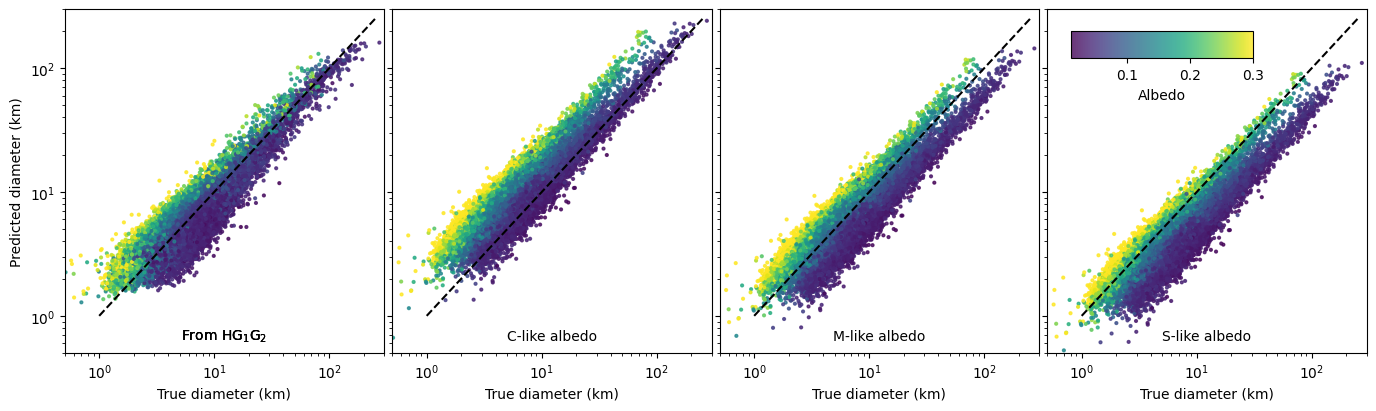

In [79]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(14, 4),
    sharey=True,
    gridspec_kw={
        "wspace": 0.025,
        "left": 0.05,
        "right": 0.98,
        "top": 0.98,
        "bottom": 0.12,
    },
)

xx = np.logspace(0, 2.4, 100)
vmin = 0.01
vmax = 0.3

for i, dd in enumerate([d_pred, d_pred_C, d_pred_M, d_pred_S]):

    im = ax[i].scatter(
        y, dd, s=4, alpha=0.8, c=data.loc[mask, "albedo.value"], vmin=vmin, vmax=vmax
    )
    ax[i].plot(xx, xx, color="black", linestyle="--")

axin = ax[3].inset_axes([0.8, 120, 30, 80], transform=ax[3].transData)
cbar = fig.colorbar(im, cax=axin, orientation="horizontal", label="Albedo")

for i, tt in enumerate(["C", "M", "S"]):
    ax[i + 1].text(
        0.5,
        0.05,
        s=f"{tt}-like albedo",
        transform=ax[i+1].transAxes,
        ha="center",
        va="center",
    )

    ax[0].text(
        0.5,
        0.05,
        s="From HG$_1$G$_2$",
        transform=ax[0].transAxes,
        ha="center",
        va="center",
    )


for a in ax:
    a.set_xscale("log")
    a.set_yscale("log")
    a.set_xlabel("True diameter (km)")
    a.set_xlim(0.5, 300)
    a.set_ylim(0.5, 300)
ax[0].set_ylabel("Predicted diameter (km)")

fig.savefig("/home/bcarry/diameter_prediction.png", dpi=300)

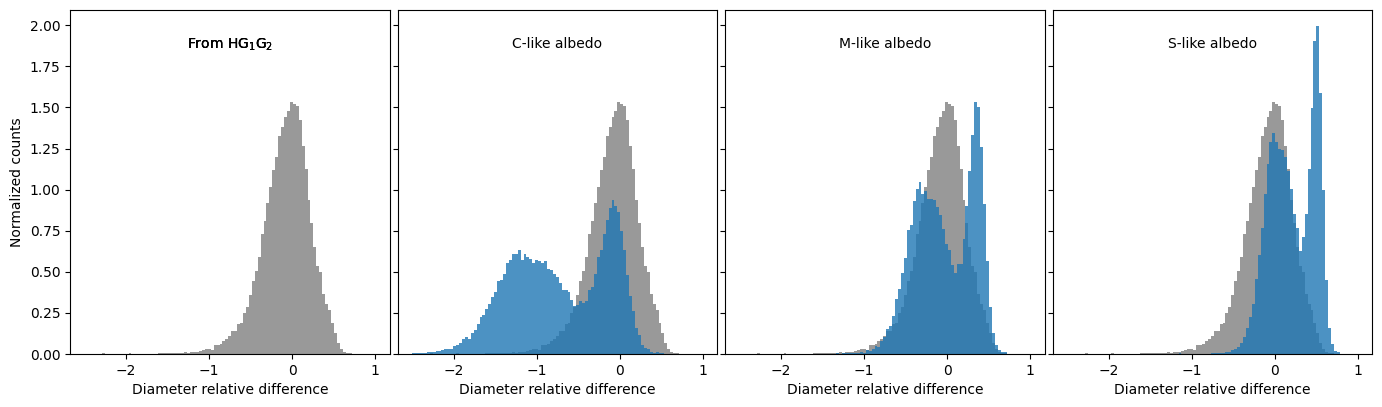

In [89]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(14, 4),
    sharey=True,
    gridspec_kw={
        "wspace": 0.025,
        "left": 0.05,
        "right": 0.98,
        "top": 0.98,
        "bottom": 0.12,
    },
)

bins = np.linspace(-2.5, 1, 100)

# for i, dd in enumerate([d_pred, d_pred_C, d_pred_M, d_pred_S]):
#     ax[i].hist((y - d_pred) / y, bins=bins, density=True, color='gray', zorder=-3, alpha=0.8)
#    ax[i].hist((y - dd) / y, bins=bins, density=True, alpha=0.8)

for i in range(4):
    ax[i].hist((y - d_pred) / y, bins=bins, density=True, color='gray', zorder=-3, alpha=0.8)

for i, dd in enumerate([d_pred_C, d_pred_M, d_pred_S]):
    ax[i+1].hist((y - dd) / y, bins=bins, density=True, alpha=0.8)



for i, tt in enumerate(["C", "M", "S"]):
    ax[i + 1].text(
        0.5,
        0.90,
        s=f"{tt}-like albedo",
        transform=ax[i+1].transAxes,
        ha="center",
        va="center",
    )

    ax[0].text(
        0.5,
        0.90,
        s="From HG$_1$G$_2$",
        transform=ax[0].transAxes,
        ha="center",
        va="center",
    )


for a in ax:
    a.set_xlabel("Diameter relative difference")
ax[0].set_ylabel("Normalized counts")

fig.savefig("/home/bcarry/diameter_hist.png", dpi=300)

Text(0.5, 0, 'Count')

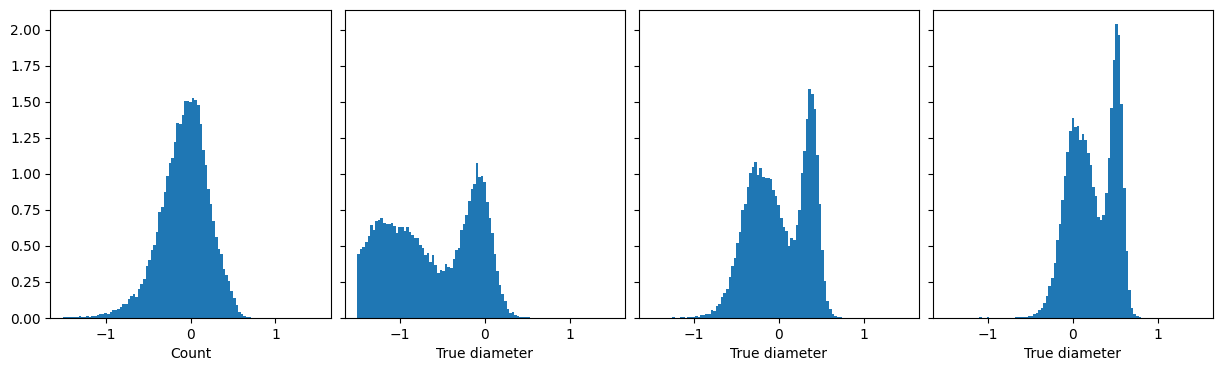

In [41]:
fig, ax = plt.subplots(
    1, 4, figsize=(15, 4), sharex=True, sharey=True, gridspec_kw={"wspace": 0.05}
)

vmin = 0.01
vmax = 0.3

bins = np.linspace(-1.5, 1.5, 100)

for i, dd in enumerate([d_pred, d_pred_C, d_pred_M, d_pred_S]):

    ax[i].hist((y - dd) / y, bins=bins, density=True)


for a in ax:
    # a.set_xscale("log")
    # a.set_yscale("log")
    a.set_xlabel("True diameter")
    # a.set_ylabel("Predicted diameter")

ax[0].set_xlabel("Count")

Text(0, 0.5, '1 - pred/true')

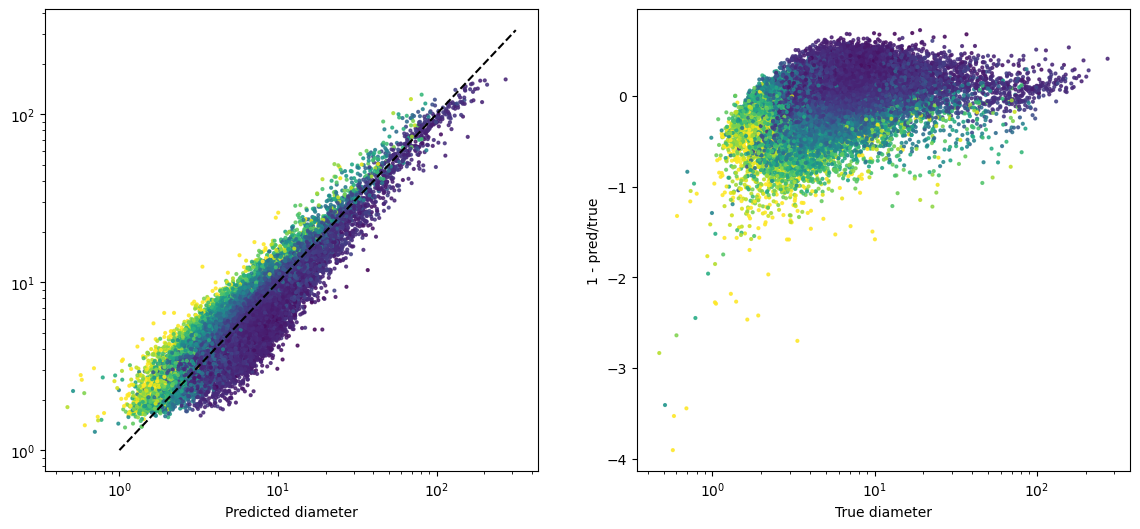

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

vmin = 0.01
vmax = 0.3

xx = np.logspace(0, 2.5, 100)

# d_pred = neigh.predict(X_train)


ax[0].scatter(
    y, d_pred, s=4, alpha=0.8, c=data.loc[mask, "albedo.value"], vmin=vmin, vmax=vmax
)
ax[1].scatter(
    y,
    (y - d_pred) / y,
    s=4,
    alpha=0.8,
    c=data.loc[mask, "albedo.value"],
    vmin=vmin,
    vmax=vmax,
)

ax[0].plot(xx, xx, color="black", linestyle="--")

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("True diameter")
ax[0].set_xlabel("Predicted diameter")


ax[1].set_xscale("log")
ax[1].set_xlabel("True diameter")
ax[1].set_ylabel("1 - pred/true")

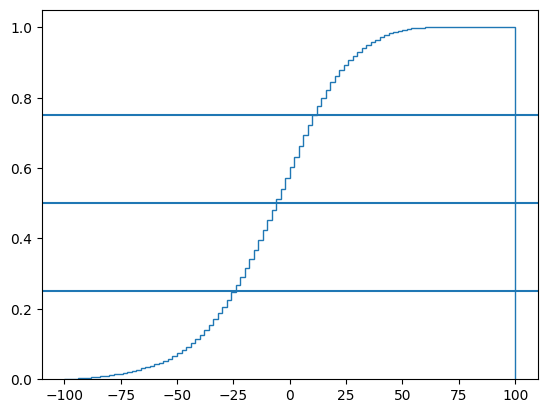

In [32]:
fig, ax = plt.subplots()

# ax.hist(  100*(y - d_pred) / y, bins=100, range=(-100,100));
ax.hist(
    100 * (y - d_pred) / y,
    bins=100,
    range=(-100, 100),
    cumulative=True,
    density=True,
    histtype="step",
)
ax.axhline(0.5)
ax.axhline(0.25)
ax.axhline(0.75)

ValueError: x and y must be the same size

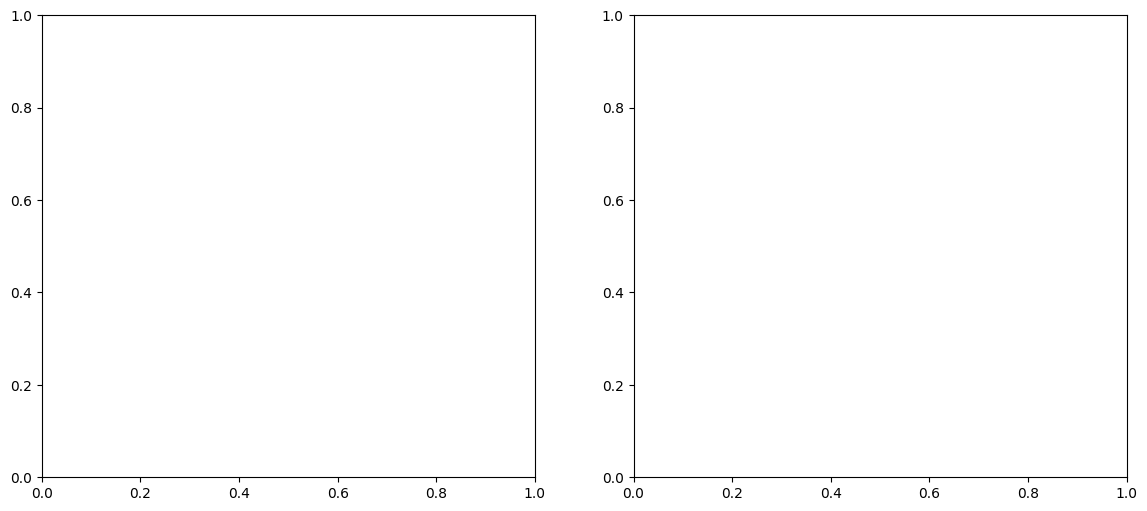

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

vmin = 0.01
vmax = 0.3

xx = np.logspace(0, 2.5, 100)

# d_pred = neigh.predict(X_train)


ax[0].scatter(D_train, d_pred, s=4, alpha=0.8)
ax[1].scatter(D_train, (D_train - d_pred) / D_train, s=4, alpha=0.8)

ax[0].plot(xx, xx, color="black", linestyle="--")

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("True diameter")


ax[1].set_xscale("log")
ax[1].set_xlabel("True diameter")

In [28]:
# Build output map
N = 201
xy = np.array(
    [(i, j) for j in np.linspace(0, 1, num=N) for i in np.linspace(0, 1, num=N)]
)
xy = np.tril(xy)

z = np.tril(reg.predict(xy).reshape(N, N)[::-1])

unity = np.triu(np.full((N, N), 1))
z = z + unity

# z = reg.predict(xy).reshape(N,N)
z = neigh.predict(xy).reshape(N, N)
#

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

filt = "r"
im = ax[0].scatter(
    data.loc[mask, f"{flavor}_G1_{filt}"],
    data.loc[mask, f"{flavor}_G2_{filt}"],
    c=data.loc[mask, "albedo.value"],
    vmin=0,
    vmax=0.2,
    # cmap='afmhot',
    s=1,
    alpha=1,
)

# ax[1].imshow(z, extent=(0,1,0,1), vmin=0, vmax=0.2, aspect='auto')
ax[1].imshow(z, extent=(0, 1, 0, 1), origin="lower", vmin=0, vmax=0.2, aspect="auto")

# cbar = fig.colorbar(im, ax=ax[1], label="Albedo")

# Axes
x = np.linspace(0, 1, 10)
for a in ax:

    a.plot(x, 1 - x, color="black", linestyle="--")
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    a.set_ylabel("G2")
    a.set_xlabel("G1")

ax[0].set_title("Data")
ax[1].set_title("Regression")

fig.tight_layout()
fig.savefig("/home/bcarry/G1G2_albedo_regression.png")

In [19]:
# save
with open("model.pkl", "wb") as f:
    pickle.dump(neigh, f)